In [4]:
import pandas as pd 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [3]:
def read_mas(filepath: str) -> pd.DataFrame:
    with open(filepath, "r") as f:
        header_line = f.readline().strip()
    cols = [c.strip().strip('"') for c in header_line.split(",")]
    return pd.read_csv(filepath, sep=r"\s+", skiprows=1, names=cols)

def load_mas_file(filename):
    try:
        with open(filename, "r") as fp:
            line = fp.readline()

        keynames = [key.strip().strip('"') for key in line.split(",")]

        data = np.genfromtxt(filename, skip_header=1)

        if data.ndim == 1:
            data = data.reshape(1, -1)

        if data.shape[1] != len(keynames):
            raise ValueError(
                f"Column mismatch in {filename}: "
                f"{len(keynames)} headers, {data.shape[1]} data columns"
            )

        df = pd.DataFrame(data, columns=keynames)
        return df
    except Exception as e:
        print(f"Failed to load {filename}: {e}")
        return None
        

In [32]:
cases = [
    "Case_0",
    "Case_1a",
    "Case_1b",
    "Case_1c",
    "Case_2a",
    "Case_2b",
    "Case_2c",
    "Case_3a",
    "Case_3b",
]

colors = cm.tab10.colors
case_colors = {case: colors[i % len(colors)] for i, case in enumerate(cases)}


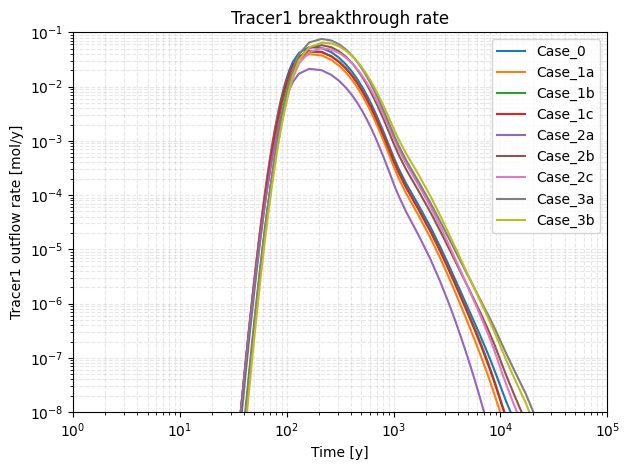

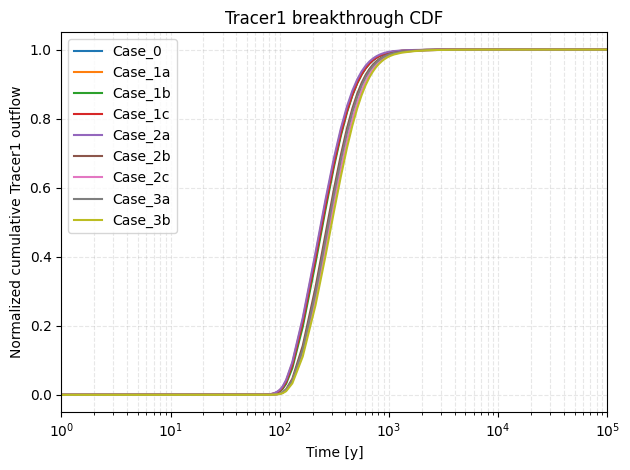

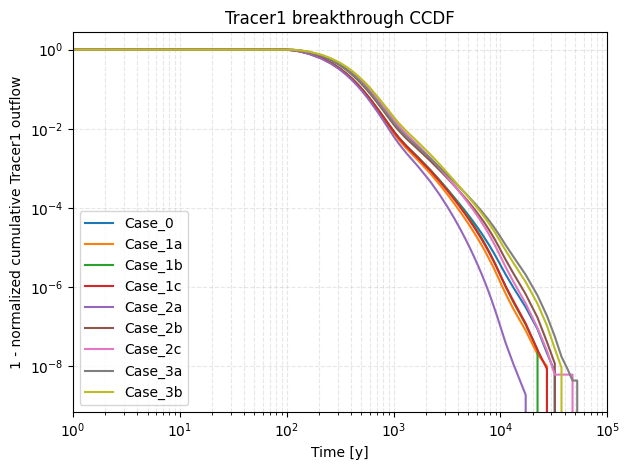

In [33]:

fig, ax = plt.subplots()
fig_cdf, ax_cdf = plt.subplots()
fig_ccdf, ax_ccdf = plt.subplots()

for case in cases:
    mas_filename = f"outputs/sample_x01_{case}-mas.dat"
    df = read_mas(mas_filename)

    outflow_rate = -1 * df["OUTFLOW Tracer1 [mol/y]"]
    outflow_cumulative = -1 * df["OUTFLOW Tracer1 [mol]"]
    cdf = outflow_cumulative / outflow_cumulative.max()
    ccdf = 1 - cdf

    color = case_colors[case]

    ax.loglog(df["Time [y]"], outflow_rate, label=case, color=color)
    ax_cdf.semilogx(df["Time [y]"], cdf, label=case, color=color)
    ax_ccdf.loglog(df["Time [y]"], ccdf, label=case, color=color)

ax.set_xlabel("Time [y]")
ax.set_ylabel("Tracer1 outflow rate [mol/y]")
ax.set_title("Tracer1 breakthrough rate")
ax.legend()
ax.grid(True, which="both", ls="--", alpha=0.3)
ax.set_xlim(1, 10**5)
ax.set_ylim(10**-8, 10**-1)

ax_cdf.set_xlabel("Time [y]")
ax_cdf.set_ylabel("Normalized cumulative Tracer1 outflow")
ax_cdf.set_title("Tracer1 breakthrough CDF")
ax_cdf.legend()
ax_cdf.grid(True, which="both", ls="--", alpha=0.3)
ax_cdf.set_xlim(1, 10**5)
ax_cdf.set_ylim(-0.05, 1.05)

ax_ccdf.set_xlabel("Time [y]")
ax_ccdf.set_ylabel("1 - normalized cumulative Tracer1 outflow")
ax_ccdf.set_title("Tracer1 breakthrough CCDF")
ax_ccdf.legend()
ax_ccdf.grid(True, which="both", ls="--", alpha=0.3)
ax_ccdf.set_xlim(1, 10**5)

fig.tight_layout()
fig_cdf.tight_layout()
fig_ccdf.tight_layout()

plt.show()

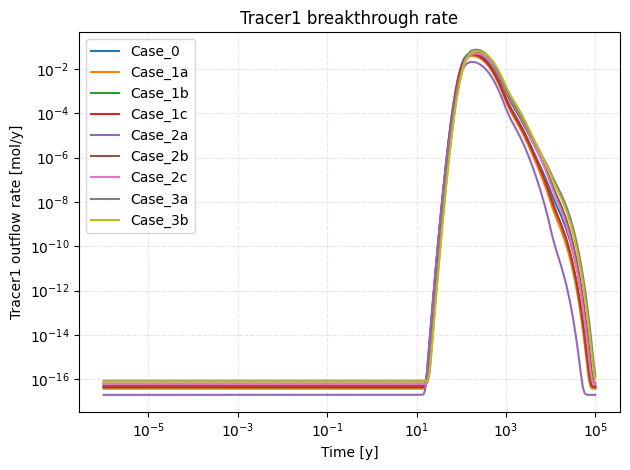

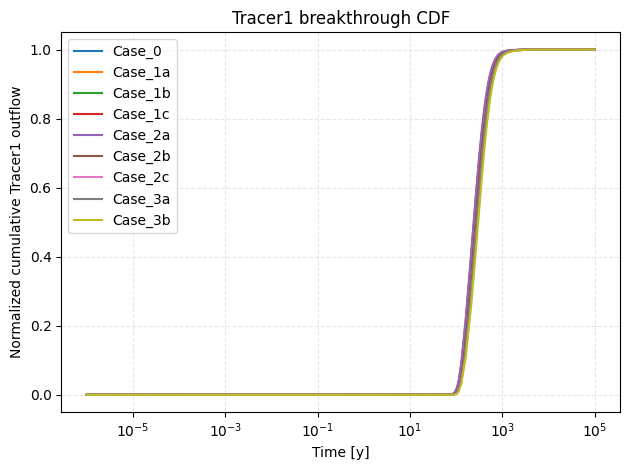

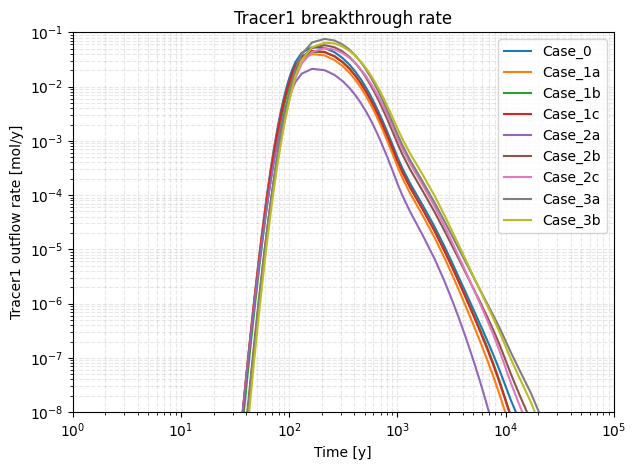

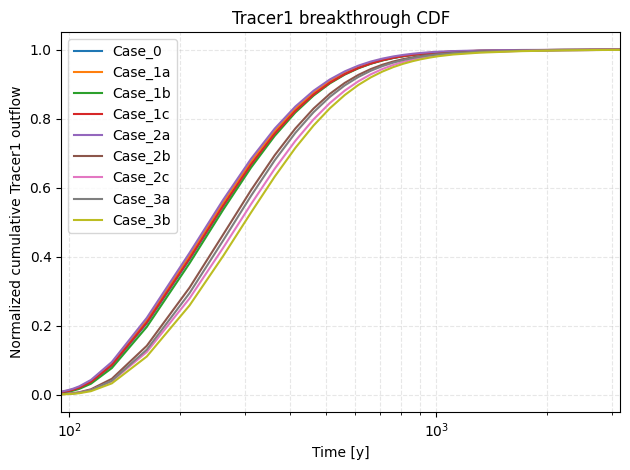

In [31]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

cases = [
    "Case_0",
    "Case_1a",
    "Case_1b",
    "Case_1c",
    "Case_2a",
    "Case_2b",
    "Case_2c",
    "Case_3a",
    "Case_3b",
]

colors = cm.tab10.colors  # 10 distinct colors, enough for 9 cases
case_colors = {case: colors[i % len(colors)] for i, case in enumerate(cases)}

fig, ax = plt.subplots()
fig_cdf, ax_cdf = plt.subplots()

for case in cases:
    mas_filename = f"outputs/sample_x01_{case}-mas.dat"
    df = read_mas(mas_filename)

    outflow_rate = -1 * df["OUTFLOW Tracer1 [mol/y]"]
    outflow_cumulative = -1 * df["OUTFLOW Tracer1 [mol]"]

    color = case_colors[case]

    ax.loglog(df["Time [y]"], outflow_rate, label=case, color=color)
    ax_cdf.semilogx(
        df["Time [y]"],
        outflow_cumulative / outflow_cumulative.max(),
        label=case,
        color=color,
    )

ax.set_xlabel("Time [y]")
ax.set_ylabel("Tracer1 outflow rate [mol/y]")
ax.set_title("Tracer1 breakthrough rate")
ax.legend()
ax.grid(True, which="both", ls="--", alpha=0.3)
# ax.axis([10, 10**5, 10**-8, 10**-1])

ax_cdf.set_xlabel("Time [y]")
ax_cdf.set_ylabel("Normalized cumulative Tracer1 outflow")
ax_cdf.set_title("Tracer1 breakthrough CDF")
ax_cdf.legend()
ax_cdf.grid(True, which="both", ls="--", alpha=0.3)

fig.tight_layout()
fig_cdf.tight_layout()

ax.set_xlim(1, 10**5)
ax.set_ylim(10**-8, 10**-1)

ax_cdf.set_xlim(95, 10**3.5)
ax_cdf.set_ylim(-0.05, 1.05)
plt.show()